In [ ]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed,
)

from sklearn.metrics import accuracy_score, f1_score

import matplotlib.pyplot as plt

DATA_DIR = Path("/egr/research-seit/kayhanmu/nlp_paper/tweeteval_sentiment")
print("DATA_DIR exists:", DATA_DIR.exists())

mapping_path = DATA_DIR / "mapping.txt"
print("\nmapping.txt:\n")
print(mapping_path.read_text())

mapping = {}
for line in mapping_path.read_text().splitlines():
    line = line.strip()
    if not line:
        continue
    idx, label_name = line.split("\t")
    mapping[int(idx)] = label_name

print("\nParsed mapping:", mapping)

neg_label = None
for k, v in mapping.items():
    if "neg" in v.lower():  
        neg_label = k
        break
print("Negative label id:", neg_label, "->", mapping[neg_label] if neg_label is not None else None)

def load_split(split: str) -> pd.DataFrame:
    text_path = DATA_DIR / f"{split}_text.txt"
    label_path = DATA_DIR / f"{split}_labels.txt"
    
    texts = text_path.read_text(encoding="utf-8").splitlines()
    labels = [int(x) for x in label_path.read_text(encoding="utf-8").splitlines()]
    assert len(texts) == len(labels), f"Length mismatch in {split}"
    return pd.DataFrame({"text": texts, "label": labels})


train_df = load_split("train")
val_df   = load_split("val")
test_df  = load_split("test")

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts().sort_index(), "\n")

print("Val label distribution:")
print(val_df["label"].value_counts().sort_index(), "\n")

print("Test label distribution:")
print(test_df["label"].value_counts().sort_index())


2025-11-25 23:07:41.310006: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-25 23:07:41.372073: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-25 23:07:45.062660: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


DATA_DIR exists: True

mapping.txt:

0	negative
1	neutral
2	positive


Parsed mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}
Negative label id: 0 -> negative
Train shape: (45615, 2)
Val shape:   (2000, 2)
Test shape:  (12284, 2)

Train label distribution:
label
0     7093
1    20673
2    17849
Name: count, dtype: int64 

Val label distribution:
label
0    312
1    869
2    819
Name: count, dtype: int64 

Test label distribution:
label
0    3972
1    5937
2    2375
Name: count, dtype: int64


In [ ]:
identity_keywords = {

    "religion_muslim": [
        "muslim", "muslims",
        "islam", "islamic", "islamist", "islamists",
        "quran", "koran",
        "allah",
        "mosque", "mosques",
        "sunni", "shia", "shiite", "salafi"
    ],
    "religion_christian": [
        "christian", "christians", "christianity",
        "jesus", "jesus christ", "christ",
        "bible", "biblical",
        "church", "churches",
        "catholic", "catholics", "catholicism",
        "protestant", "protestants",
        "evangelical", "evangelicals",
        "pastor", "priest"
    ],
    "religion_jewish": [
        "jew", "jews", "jewish",
        "judaism",
        "synagogue", "synagogues",
        "rabbi", "rabbis",
        "zionist", "zionists", "zionism",
        "israel", "israeli", "israelis"
    ],
    "religion_atheist": [
        "atheist", "atheists", "atheism",
        "agnostic", "agnostics", "agnosticism",
        "secular", "secularist", "secularists"
    ],

    "race_black": [
        "black people", "black person",
        "black man", "black woman",
        "black men", "black women",
        "blacks",
        "african american", "african americans"
    ],
    "race_white": [
        "white people", "white person",
        "white man", "white woman",
        "white men", "white women",
        "whites",
        "caucasian", "caucasians"
    ],
    "race_asian": [
        "asian", "asians",
        "east asian", "east asians",
        "chinese", "japanese", "korean",
        "indian", "indians"
    ],
    "race_hispanic": [
        "hispanic", "hispanics",
        "latino", "latina", "latinos", "latinas",
        "mexican", "mexicans", "chicano", "chicanos"
    ],

    "country_usa": [
        "usa", "u.s.a.", "u.s.",
        "america", "american", "americans",
        "united states"
    ],
    "country_uk": [
        "uk", "u.k.", "united kingdom",
        "britain", "british",
        "england", "english"
    ],
    "country_iran": [
        "iran", "iranian", "iranians",
        "persia", "persian", "persians"
    ],
    "country_russia": [
        "russia", "russian", "russians",
        "kremlin", "moscow"
    ],
}


def find_groups(text: str):

    text_low = text.lower()
    groups = set()
    for group, kws in identity_keywords.items():
        for kw in kws:
            pattern = r"(?<!\w)" + re.escape(kw) + r"(?!\w)"
            if re.search(pattern, text_low):
                groups.add(group)
                break
    return list(groups)

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    all_groups = Counter()
    group_lists = df["text"].apply(find_groups)
    for gs in group_lists:
        all_groups.update(gs)
    num_with_any = sum(1 for gs in group_lists if len(gs) > 0)

    print(f"\n=== {split_name.upper()} split ===")
    print(f"Total tweets: {len(df)}")
    print(f"Tweets with at least one identity group: {num_with_any}")
    print("Counts per group:")
    for g, c in all_groups.most_common():
        print(f"  {g:20s}: {c}")



=== TRAIN split ===
Total tweets: 45615
Tweets with at least one identity group: 3070
Counts per group:
  religion_muslim     : 723
  religion_christian  : 709
  country_usa         : 622
  country_uk          : 458
  religion_jewish     : 329
  country_iran        : 260
  race_asian          : 139
  country_russia      : 85
  race_black          : 34
  race_hispanic       : 30
  religion_atheist    : 22
  race_white          : 11

=== VAL split ===
Total tweets: 2000
Tweets with at least one identity group: 152
Counts per group:
  religion_muslim     : 37
  country_usa         : 33
  country_uk          : 28
  religion_christian  : 25
  religion_jewish     : 14
  country_iran        : 10
  country_russia      : 7
  race_asian          : 3
  race_black          : 2
  religion_atheist    : 1

=== TEST split ===
Total tweets: 12284
Tweets with at least one identity group: 1133
Counts per group:
  country_usa         : 310
  religion_jewish     : 209
  country_russia      : 180
  country

In [ ]:

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

train_ds = Dataset.from_pandas(train_df)
val_ds   = Dataset.from_pandas(val_df)
test_ds  = Dataset.from_pandas(test_df)

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok   = val_ds.map(tokenize_batch, batched=True)
test_tok  = test_ds.map(tokenize_batch, batched=True)

cols_to_keep = ["input_ids", "attention_mask", "label"]

def cleanup_dataset(ds):
    drop_cols = [c for c in ds.column_names if c not in cols_to_keep]
    ds = ds.remove_columns(drop_cols)
    ds.set_format("torch")
    return ds

train_tok = cleanup_dataset(train_tok)
val_tok   = cleanup_dataset(val_tok)
test_tok  = cleanup_dataset(test_tok)

print(train_tok)
print(val_tok)
print(test_tok)


Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 45615
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 2000
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 12284
})


In [ ]:
num_labels = len(mapping)
print("num_labels:", num_labels)

set_seed(42) 

model_base = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
)

def compute_metrics_multi(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1_macro}

training_args_base = TrainingArguments(
    output_dir="./sentiment_bert_base",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=100,
)

trainer_base = Trainer(
    model=model_base,
    args=training_args_base,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics_multi,
)

trainer_base.train()

raw_preds_base = trainer_base.predict(test_tok)
logits_base = raw_preds_base.predictions
y_true = raw_preds_base.label_ids              
y_pred_base = np.argmax(logits_base, axis=-1)   

print("\n=== BASELINE TEST METRICS ===")
print("Baseline accuracy:", accuracy_score(y_true, y_pred_base))
print("Baseline macro-F1:", f1_score(y_true, y_pred_base, average="macro"))


num_labels: 3


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.636200,0.606772,0.733500,0.715490
2,0.539900,0.597880,0.751500,0.732048
3,0.464100,0.620468,0.743000,0.723221


/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; w


=== BASELINE TEST METRICS ===
Baseline accuracy: 0.6996906545099316
Baseline macro-F1: 0.6970000595729219


In [ ]:
test_df_base = test_df.copy()
test_df_base["groups"] = test_df_base["text"].apply(find_groups)
test_df_base["y_true"] = y_true
test_df_base["y_pred"] = y_pred_base

def group_label_stats(df, num_classes=3, min_count=5):
    """
    df: 'groups', 'y_true', 'y_pred' kolonlarını içeren DataFrame
    """
    all_groups = Counter()
    for gs in df["groups"]:
        all_groups.update(gs)

    results = {}
    for g, count in all_groups.items():
        if count < min_count:
            continue

        mask = df["groups"].apply(lambda xs: g in xs)
        sub = df[mask]
        yt = sub["y_true"].to_numpy()
        yp = sub["y_pred"].to_numpy()

        stats = {}
        stats["num_samples"] = int(len(sub))
        stats["acc"] = float(np.mean(yt == yp))

        for c in range(num_classes):
            stats[f"true_frac_{c}"] = float(np.mean(yt == c))
            stats[f"pred_frac_{c}"] = float(np.mean(yp == c))

        results[g] = stats

    return results

group_stats_base = group_label_stats(test_df_base, num_classes=num_labels, min_count=1)
df_base = pd.DataFrame(group_stats_base).T

print("=== Baseline group stats (first rows) ===")
display(df_base.head())


=== Baseline group stats (first rows) ===


,num_samples,acc,true_frac_0,pred_frac_0,true_frac_1,pred_frac_1,true_frac_2,pred_frac_2
religion_jewish,209.0,0.741627,0.397129,0.454545,0.545455,0.497608,0.057416,0.047847
country_usa,310.0,0.722581,0.477419,0.477419,0.435484,0.403226,0.087097,0.119355
religion_christian,94.0,0.691489,0.382979,0.308511,0.425532,0.489362,0.191489,0.202128
country_russia,180.0,0.722222,0.377778,0.450000,0.583333,0.527778,0.038889,0.022222
country_iran,43.0,0.767442,0.395349,0.558140,0.581395,0.418605,0.023256,0.023256


In [ ]:
usa_terms       = identity_keywords["country_usa"]
russia_terms    = identity_keywords["country_russia"]

christian_terms = identity_keywords["religion_christian"]
jewish_terms    = identity_keywords["religion_jewish"]

cda_pairs = [
    {
        "name": "usa_to_russia",
        "src_terms": usa_terms,
        "tgt_terms": russia_terms,
    },
    {
        "name": "christian_to_jewish",
        "src_terms": christian_terms,
        "tgt_terms": jewish_terms,
    },
]


def text_contains_any(text, terms):
   
    text_low = text.lower()
    for t in terms:
        pattern = r"(?<!\w)" + re.escape(t) + r"(?!\w)"
        if re.search(pattern, text_low):
            return True
    return False


def replace_terms(text, src_terms, tgt_terms):

    pairs = []
    for i, src in enumerate(src_terms):
        if i < len(tgt_terms):
            tgt = tgt_terms[i]
        else:
            tgt = tgt_terms[-1]  
        pairs.append((src, tgt))

    pairs_sorted = sorted(pairs, key=lambda x: len(x[0]), reverse=True)

    new_text = text
    for src, tgt in pairs_sorted:
        pattern = re.compile(r"(?<!\w)" + re.escape(src) + r"(?!\w)", flags=re.IGNORECASE)
        new_text = pattern.sub(tgt, new_text)

    return new_text


NEG_ID = None
for k, v in mapping.items():
    if "neg" in v.lower():  
        NEG_ID = k
        break
print("NEG_ID (negative label id):", NEG_ID)


def make_cda_augmentations(df, cda_pairs):

    augmented_rows = []

    for _, row in df.iterrows():
        text  = row["text"]
        label = row["label"]

        if label == NEG_ID:
            continue

        for rule in cda_pairs:
            src_terms = rule["src_terms"]
            tgt_terms = rule["tgt_terms"]

            has_src = text_contains_any(text, src_terms)
            has_tgt = text_contains_any(text, tgt_terms)

            if has_src and not has_tgt:
                new_text = replace_terms(text, src_terms, tgt_terms)
                augmented_rows.append({
                    "text": new_text,
                    "label": label,
                    "rule": rule["name"],
                })

    return pd.DataFrame(augmented_rows)

aug_train_df = make_cda_augmentations(train_df, cda_pairs)

print("Augmented counts by rule:")
print(aug_train_df["rule"].value_counts())
print("\nTotal augmented examples:", len(aug_train_df))


train_cda_df = pd.concat(
    [train_df[["text", "label"]], aug_train_df[["text", "label"]]],
    ignore_index=True,
)

print("Original train size:", len(train_df))
print("Augmented train size:", len(aug_train_df))
print("Combined train size:", len(train_cda_df))


NEG_ID (negative label id): 0
Augmented counts by rule:
rule
christian_to_jewish    524
usa_to_russia          488
Name: count, dtype: int64

Total augmented examples: 1012
Original train size: 45615
Augmented train size: 1012
Combined train size: 46627


In [ ]:
train_cda_ds = Dataset.from_pandas(train_cda_df)
train_cda_tok = train_cda_ds.map(tokenize_batch, batched=True)
train_cda_tok = cleanup_dataset(train_cda_tok)

print(train_cda_tok)

set_seed(42) 

model_cda = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
)

training_args_cda = TrainingArguments(
    output_dir="./sentiment_bert_cda",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=100,
)

trainer_cda = Trainer(
    model=model_cda,
    args=training_args_cda,
    train_dataset=train_cda_tok,
    eval_dataset=val_tok,             
    compute_metrics=compute_metrics_multi,
)

trainer_cda.train()

raw_preds_cda = trainer_cda.predict(test_tok)
logits_cda = raw_preds_cda.predictions
y_pred_cda = np.argmax(logits_cda, axis=-1)

print("\n=== CDA MODEL TEST METRICS ===")
print("CDA accuracy:", accuracy_score(y_true, y_pred_cda))
print("CDA macro-F1:", f1_score(y_true, y_pred_cda, average="macro"))

Map:   0%|          | 0/46627 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 46627
})


/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.632700,0.620258,0.725000,0.707618
2,0.520600,0.610367,0.739500,0.720753
3,0.462600,0.623678,0.740500,0.723003


/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/egr/research-seit/kayhanmu/anaconda3/envs/iot-ids/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; w


=== CDA MODEL TEST METRICS ===
CDA accuracy: 0.6958645392380333
CDA macro-F1: 0.6952193909796177



=== Groups used in plots ===
                    num_samples_base  acc_base   acc_cda
religion_jewish                209.0  0.741627  0.717703
country_usa                    310.0  0.722581  0.735484
religion_christian              94.0  0.691489  0.659574
country_russia                 180.0  0.722222  0.722222

=== Base vs CDA group stats (subset) ===


,num_samples_base,acc_base,acc_cda,true_frac_0_base,pred_frac_0_base,true_frac_0_cda,pred_frac_0_cda,true_frac_1_base,pred_frac_1_base,true_frac_1_cda,pred_frac_1_cda,true_frac_2_base,pred_frac_2_base,true_frac_2_cda,pred_frac_2_cda
religion_jewish,209.0,0.741627,0.717703,0.397129,0.454545,0.397129,0.425837,0.545455,0.497608,0.545455,0.531100,0.057416,0.047847,0.057416,0.043062
country_usa,310.0,0.722581,0.735484,0.477419,0.477419,0.477419,0.506452,0.435484,0.403226,0.435484,0.380645,0.087097,0.119355,0.087097,0.112903
religion_christian,94.0,0.691489,0.659574,0.382979,0.308511,0.382979,0.361702,0.425532,0.489362,0.425532,0.425532,0.191489,0.202128,0.191489,0.212766
country_russia,180.0,0.722222,0.722222,0.377778,0.450000,0.377778,0.461111,0.583333,0.527778,0.583333,0.516667,0.038889,0.022222,0.038889,0.022222


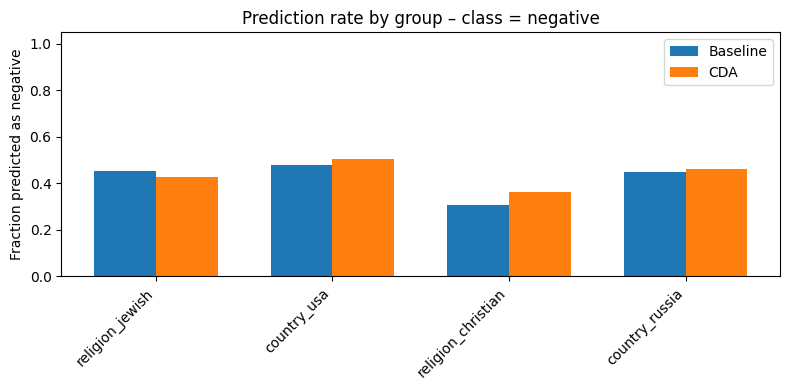

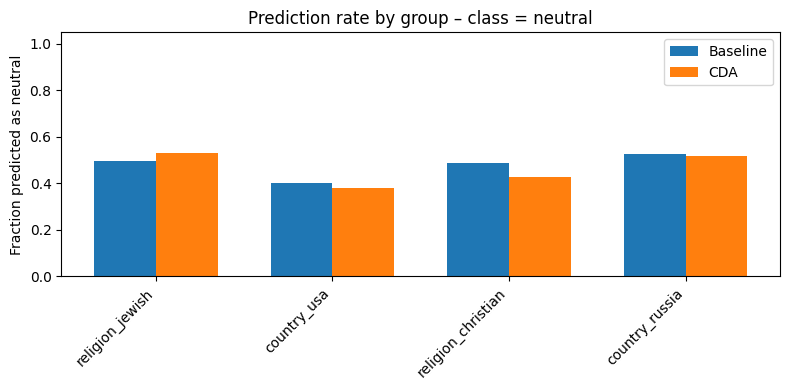

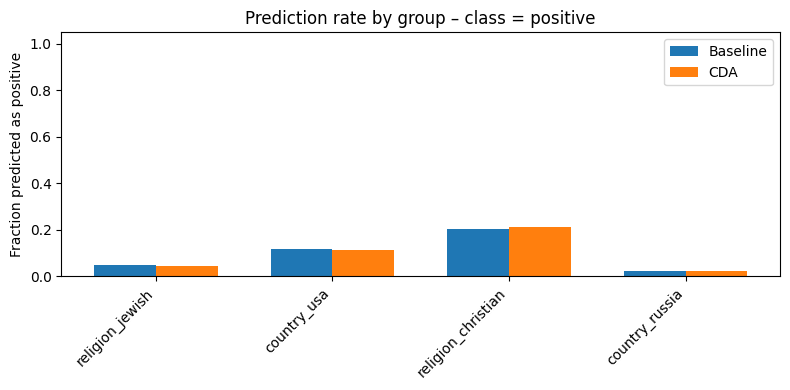

In [ ]:
test_df_cda = test_df.copy()
test_df_cda["groups"] = test_df_cda["text"].apply(find_groups)
test_df_cda["y_true"] = y_true         
test_df_cda["y_pred"] = y_pred_cda


group_stats_cda = group_label_stats(test_df_cda, num_classes=num_labels, min_count=1)
df_cda = pd.DataFrame(group_stats_cda).T

df_join = df_base.join(
    df_cda,
    lsuffix="_base",
    rsuffix="_cda",
)


MIN_N = 20
keep_groups = [
    "country_usa",
    "country_russia",
    "religion_christian",
    "religion_jewish",
   
]

df_plot = df_join[
    (df_join["num_samples_base"] >= MIN_N)
    & (df_join.index.isin(keep_groups))
].copy()

print("\n=== Groups used in plots ===")
print(df_plot[["num_samples_base", "acc_base", "acc_cda"]])

cols = [
    "num_samples_base",
    "acc_base",
    "acc_cda",
]

for c in sorted(mapping.keys()):
    label_name = mapping[c]
    cols.append(f"true_frac_{c}_base")
    cols.append(f"pred_frac_{c}_base")
    cols.append(f"true_frac_{c}_cda")
    cols.append(f"pred_frac_{c}_cda")

print("\n=== Base vs CDA group stats (subset) ===")
display(df_plot[cols]) 

groups = df_plot.index.tolist()
x = np.arange(len(groups))
width = 0.35

for c in sorted(mapping.keys()):
    label_name = mapping[c]
    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, df_plot[f"pred_frac_{c}_base"], width, label="Baseline")
    plt.bar(x + width/2, df_plot[f"pred_frac_{c}_cda"],  width, label="CDA")

    plt.xticks(x, groups, rotation=45, ha="right")
    plt.ylabel(f"Fraction predicted as {label_name}")
    plt.title(f"Prediction rate by group – class = {label_name}")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pairs = [
    ("religion_jewish", "religion_christian", "Jewish vs Christian"),
    ("country_russia",  "country_usa",        "Russia vs USA"),
]

rows = []
for g_min, g_maj, pair_name in pairs:
    for c, label_name in mapping.items():
        col_base_min = f"pred_frac_{c}_base"
        col_base_maj = f"pred_frac_{c}_base"
        col_cda_min  = f"pred_frac_{c}_cda"
        col_cda_maj  = f"pred_frac_{c}_cda"

        p_min_base = df_join.loc[g_min, col_base_min]
        p_maj_base = df_join.loc[g_maj, col_base_maj]
        p_min_cda  = df_join.loc[g_min, col_cda_min]
        p_maj_cda  = df_join.loc[g_maj, col_cda_maj]

        gap_base = p_min_base - p_maj_base
        gap_cda  = p_min_cda  - p_maj_cda

        rows.append({
            "pair": pair_name,
            "minority": g_min,
            "majority": g_maj,
            "label_id": c,
            "label_name": label_name,
            "gap_base": gap_base,
            "gap_cda": gap_cda,
            "abs_gap_base": abs(gap_base),
            "abs_gap_cda": abs(gap_cda),
        })

gap_df = pd.DataFrame(rows)
display(gap_df)


,pair,minority,majority,label_id,label_name,gap_base,gap_cda,abs_gap_base,abs_gap_cda
0,Jewish vs Christian,religion_jewish,religion_christian,0,negative,0.146035,0.064135,0.146035,0.064135
1,Jewish vs Christian,religion_jewish,religion_christian,1,neutral,0.008246,0.105569,0.008246,0.105569
2,Jewish vs Christian,religion_jewish,religion_christian,2,positive,-0.154281,-0.169704,0.154281,0.169704
3,Russia vs USA,country_russia,country_usa,0,negative,-0.027419,-0.045341,0.027419,0.045341
4,Russia vs USA,country_russia,country_usa,1,neutral,0.124552,0.136022,0.124552,0.136022
5,Russia vs USA,country_russia,country_usa,2,positive,-0.097133,-0.090681,0.097133,0.090681


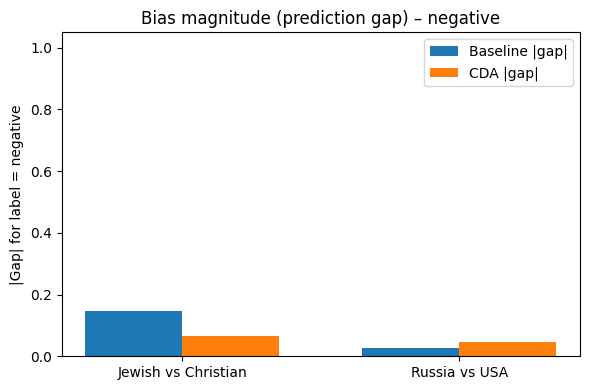

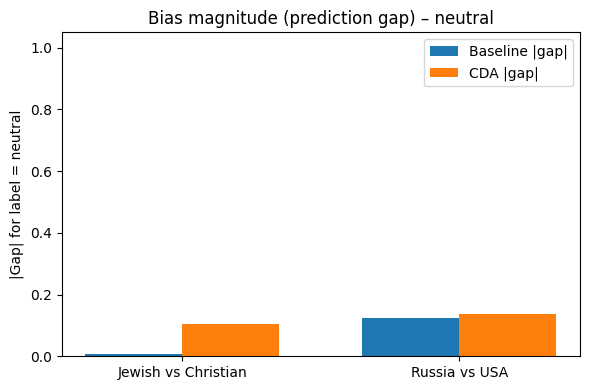

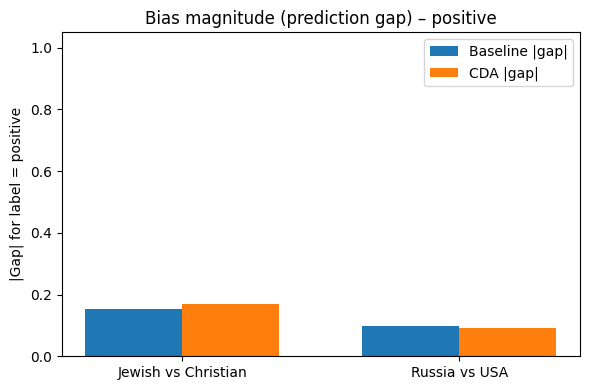

In [ ]:
label_ids_sorted = sorted(mapping.keys())
width = 0.35

for c in label_ids_sorted:
    label_name = mapping[c]
    sub = gap_df[gap_df["label_id"] == c].copy()

    x = np.arange(len(sub))

    plt.figure(figsize=(6, 4))
    plt.bar(x - width/2, sub["abs_gap_base"], width, label="Baseline |gap|")
    plt.bar(x + width/2, sub["abs_gap_cda"],  width, label="CDA |gap|")

    plt.xticks(x, sub["pair"], rotation=0)
    plt.ylabel(f"|Gap| for label = {label_name}")
    plt.title(f"Bias magnitude (prediction gap) – {label_name}")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()
